<a href="https://colab.research.google.com/github/triaanandafh/Mk_Data-Mining/blob/main/Polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')
# Baca file (sesuaikan nama filenya)
data = pd.read_csv('/content/drive/MyDrive/Kuliah/Data-mining/fuel_efficiency_speed.csv')
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,speed_kmh,fuel_consumption
0,20,8.9
1,25,7.6
2,30,6.8
3,35,6.0
4,40,5.4


In [4]:
# eksplorasi data
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmh         20 non-null     int64  
 1   fuel_consumption  20 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes


,speed_kmh,fuel_consumption
count,20.000000,20.000000
mean,67.500000,6.365000
std,29.580399,1.688436
min,20.000000,4.400000
25%,43.750000,4.950000
50%,67.500000,5.950000
75%,91.250000,7.625000
max,115.000000,9.800000


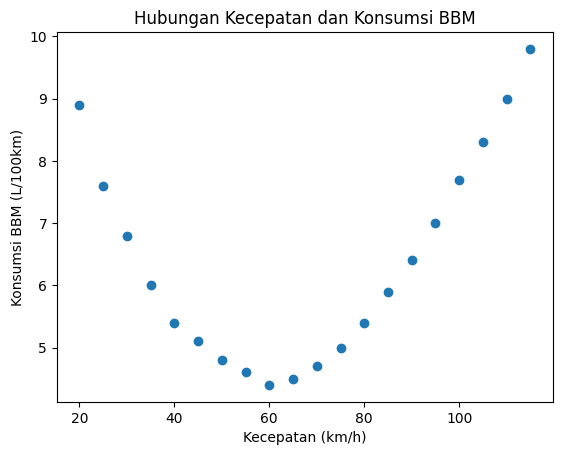

In [6]:
plt.scatter(data['speed_kmh'], data['fuel_consumption'])
plt.xlabel('Kecepatan (km/h)')
plt.ylabel('Konsumsi BBM (L/100km)')
plt.title('Hubungan Kecepatan dan Konsumsi BBM')
plt.show()

In [7]:
# pisahkan variabel independen(x) dan dependen(y)
X = data[['speed_kmh']]
y = data['fuel_consumption']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# bangun model regresi
model = LinearRegression()
model.fit(X_train_poly, y_train)

# prediksi pada data
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# evaluasi model dengan menghitung RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE Training:", rmse_train)
print("RMSE Testing:", rmse_test)

RMSE Training: 0.16936915917924067
RMSE Testing: 0.5614516586136128


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


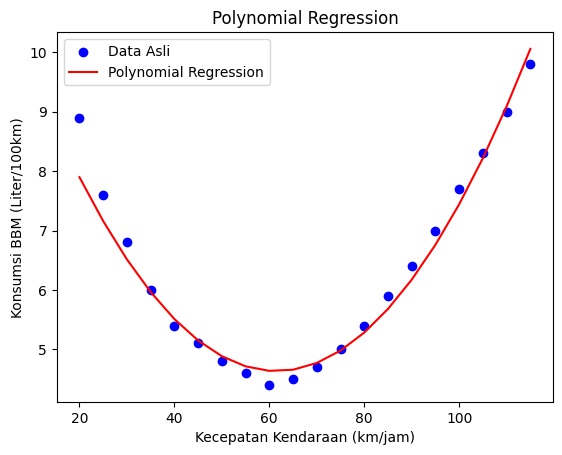

In [12]:
plt.scatter(X, y, color='blue', label='Data Asli')

X_sorted = np.sort(X.values, axis=0)
X_sorted_poly = poly.transform(X_sorted)
y_sorted_pred = model.predict(X_sorted_poly)

plt.plot(X_sorted, y_sorted_pred, color='red', label='Polynomial Regression')
plt.xlabel('Kecepatan Kendaraan (km/jam)')
plt.ylabel('Konsumsi BBM (Liter/100km)')
plt.title('Polynomial Regression')
plt.legend()
plt.show()

In [13]:
# hands on prediksi konsumsi BBM pada kecepatan 120 km/jam
new_speed = np.array([[120]])
new_speed_poly = poly.transform(new_speed)
prediction = model.predict(new_speed_poly)
print("Prediksi konsumsi BBM:", prediction[0]
)

Prediksi konsumsi BBM: 11.119871893797004


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
